<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter5/5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 결정트리

## 로지스틱회귀로 와인 분류


In [2]:
#데이터 준비
import pandas as pd

wine = pd.read_csv('https://bit.ly/wine_csv_data')

#class에서 0이면 레드 와인, 1이면 화이트 와인(화이트 와인이 양성 클래스인 이진 분류)
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [4]:
#info() 메서드
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [5]:
#describe() 메서드. 열에 대한 간략한 통계 출력
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [9]:
#훈련을 위한 데이터 전처리
data = wine[['alcohol', 'sugar', 'pH']]
target = wine['class']

In [12]:
#훈련세트와 테스트 세트 나누기(샘플의 개수가 많으므로 test_size를 0.2로 설정해서 20퍼 정도를 테스트 세트로 지정)
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size = 0.2, random_state=42)

print(train_input.shape, test_input.shape)

(5197, 3) (1300, 3)


In [14]:
#도수, 당도, pH의 스케일이 다르니 표준화
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_input)

train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [16]:
#로지스틱 회귀로 훈련시키기
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(train_scaled, train_target)

#스코어 확인(점수가 딱히 높지 않으니 다소 과소적합이 된듯)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

0.7808350971714451
0.7776923076923077


In [17]:
#계수와 절편(이 계수와 절편으로 나온 값이 0보다 크면 화이트와인, 작으면 레드와인)(이해하기 어려움)
print(lr.coef_, lr.intercept_)

[[ 0.51268071  1.67335441 -0.68775646]] [1.81773456]


## 결정트리
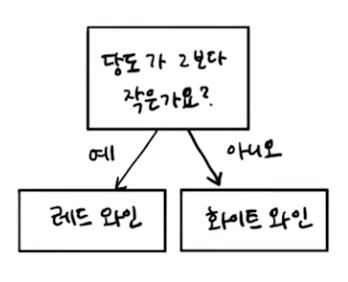

In [18]:
#결정트리 훈련시키기
from sklearn.tree import DecisionTreeClassifier

#결정트리는 무작위성을 가지고 있어서 random_state 사용
dt = DecisionTreeClassifier(random_state=42)
dt.fit(train_scaled, train_target)

#스코어 확인
print(dt.score(train_scaled, train_target))
print(dt.score(test_scaled, test_target))

0.996921300750433
0.8569230769230769


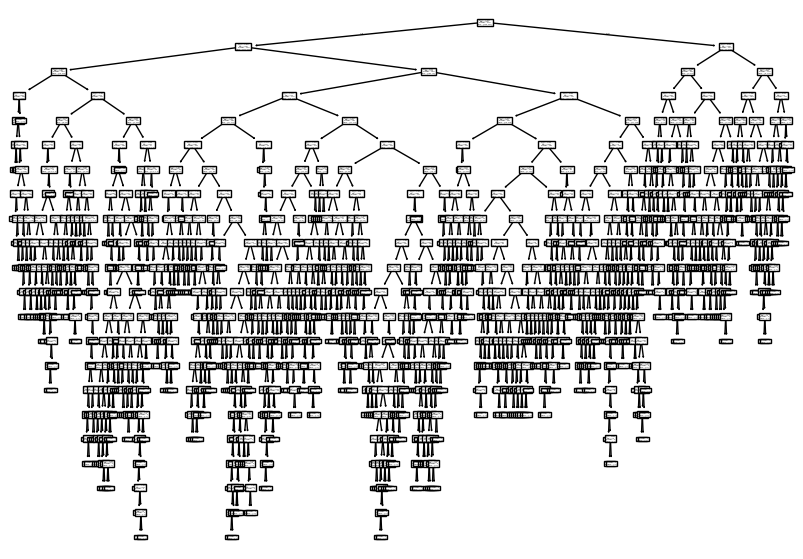

In [20]:
#그림으로 표현해보기
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,7))
plot_tree(dt)
plt.show()

맨 위의 노드를 `루트 노드`, 맨 아래 노드를 `리프 노드`라 한다.

노드는 결정 트리를 구성하는 핵심 요소이다. 노드는 훈련 데이터의 특성에 대한 테스트를 표현한다.

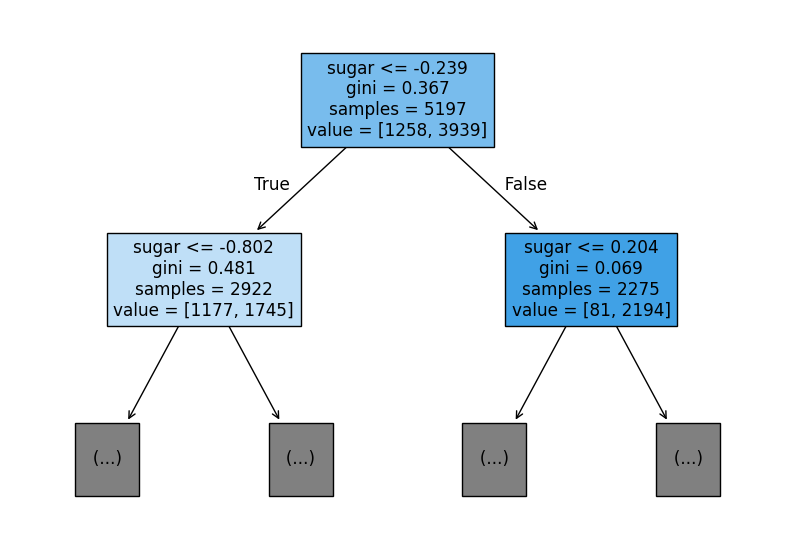

In [22]:
#트리가 너무 복잡하므로 plot_tree() 에서 깊이를 제한해서 출력.
#max_depth를 1로 주면 루트노드를 제외하고 하나의 노드를 확장하여 그리고 나머지는 생략.

plt.figure(figsize=(10,7))
plot_tree(dt, max_depth=1, filled=True,
          feature_names = ['alcohol', 'sugar', 'pH'])

plt.show()

결정트리에서 예측

리프 노드에서 가장 많은 클래스가 예측 클래스가 됨.

## 지니 불순도

샘플의 밸류에서 음성 클래스와 양성 클래스가 많이 섞여있으면 불순도가 높음.

불순도가 낮도록 계속 노드를 분할하는것이 트리 모델

부모와 자식 노드 사이의 불순도 차이를 정보이득이라고 부르는데 이 알고리즘은 정보 이득이 최대가 되도록 데이터를 나눈다. 이때 지니 불순도를 기준으로 사용함.

하지만 사이킷런에는 또 다른 불순도 기준이 있긴함.
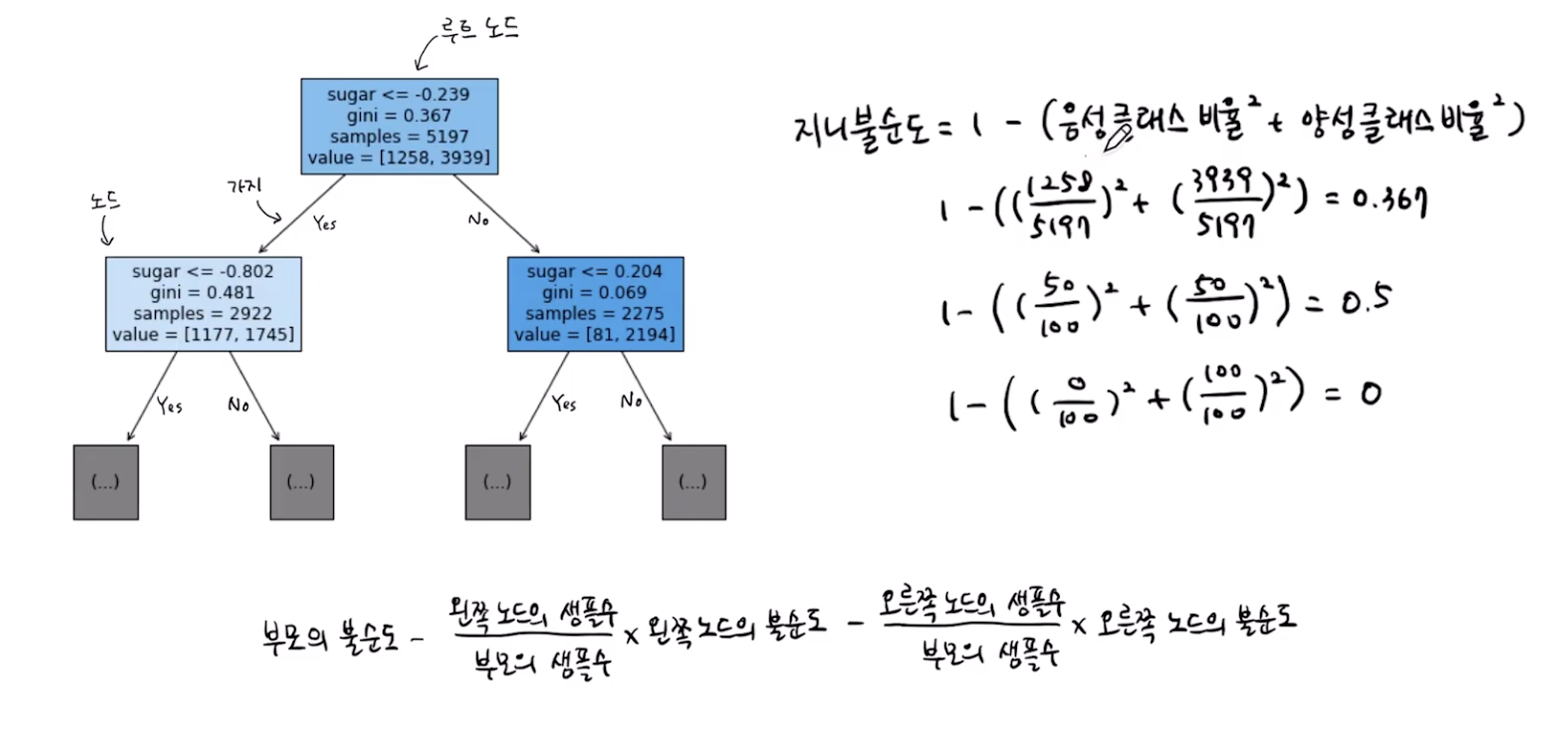


## 가지치기
훈련세트에만 잘맞고 테스트 세트에서 점수는 그에 못 미치는 상황(일반화가 잘 안될 것 같다고 말하는 상황)을 막기 위해 가지치기하기.


In [25]:
#트리의 깊이를 조정해서 다시 훈련
#스케일 조정하지 않는 특성을 사용해도 됨. 결정 트리의 장점.
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(train_input, train_target)

#스코어 확인(과대적합 완화)
print(dt.score(train_input, train_target))
print(dt.score(test_input, test_target))

0.8454877814123533
0.8415384615384616


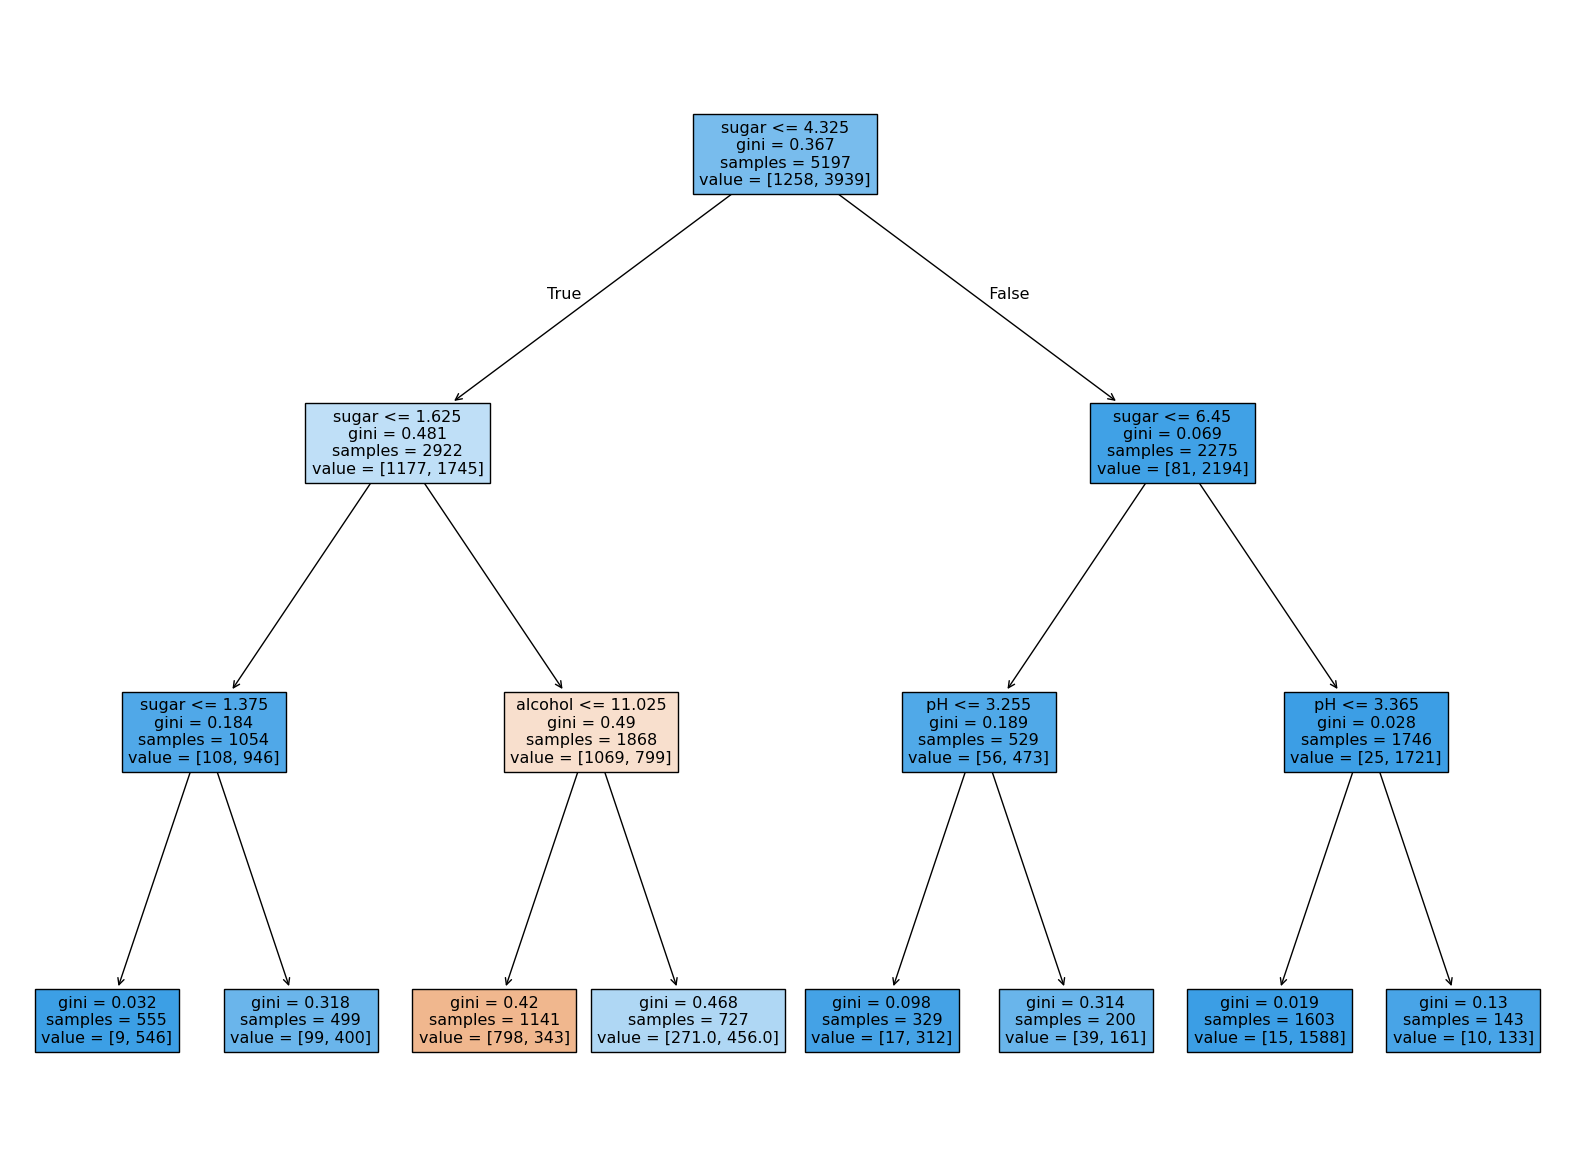

In [26]:
#그림으로 표현하기
plt.figure(figsize=(20,15))
plot_tree(dt, filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()

In [27]:
#어떤 특성이 가장 유용한지 나타내는 특성 중요도 계산
print(dt.feature_importances_)

[0.12345626 0.86862934 0.0079144 ]


로지스틱 회귀 모델로 하니까 이해가 어려움 -> 경정 트리를 사용해서 분류 -> 깊이가 깊지 않다면 설명하기 좋음.